# Customer Feedback Analysis & Automated Response
**Goal:** find the urgent negative reviews, see what customers complain about, and use Gen AI to write apology emails.
Only Python, Pandas and charts are used - **no machine learning**.

## 1. Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings("ignore")

## 2. Load the data

In [4]:
# upload the file to Colab, right click it -> Copy path, and paste it below
df = pd.read_csv("/content/Womens Clothing E-Commerce Reviews.csv.zip")
df

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [5]:
df.shape

(23486, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


## 3. Handle missing values
- no review text or no rating -> the row is useless, so **drop** it
- missing Age / numbers -> fill with the **median** (middle value)
- missing categories -> fill with the **most common value (mode)**
- missing title -> fill with empty text

In [7]:
df.isna().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [8]:
df.drop("Unnamed: 0", axis=1, inplace=True, errors="ignore")      # extra index column

df = df.dropna(subset=["Review Text", "Rating"])                   # rows without text or rating

df["Title"] = df["Title"].fillna("")
df["Age"] = df["Age"].fillna(df["Age"].median())

for i in ["Division Name", "Department Name", "Class Name"]:
    df[i] = df[i].fillna(df[i].mode()[0])

df = df.drop_duplicates(subset=["Review Text"]).reset_index(drop=True)   # remove repeated reviews

df.isna().sum()

,0
Clothing ID,0
Age,0
Title,0
Review Text,0
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,0
Department Name,0
Class Name,0


## 4. Clean the text
We make a **new** column `clean_review` (lower case, no special characters). The original text stays safe in `Review Text` so we can quote it in the emails.

In [9]:
df["clean_review"] = df["Review Text"].str.lower()                                     # small letters
df["clean_review"] = df["clean_review"].str.replace(r"[^a-z\s]", " ", regex=True)      # remove special characters and numbers
df["clean_review"] = df["clean_review"].str.replace(r"\s+", " ", regex=True).str.strip()   # remove extra spaces

df[["Review Text", "clean_review"]].head()

,Review Text,clean_review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress it s sooo pretty i happened to...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it s fun flirty...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...


## 5. Feature Engineering
Feature engineering = **making new useful columns from the existing ones**.

### 5.1 Text features
Angry customers often write long reviews and use `!!!`, so we measure these.

In [10]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,clean_review
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,absolutely wonderful silky and sexy and comfor...
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,love this dress it s sooo pretty i happened to...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,i had such high hopes for this dress and reall...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,i love love love this jumpsuit it s fun flirty...
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,this shirt is very flattering to all due to th...


In [11]:
df["char_count"] = df["Review Text"].str.len()                    # number of characters
df["word_count"] = df["clean_review"].str.split().str.len()       # number of words
df["exclamation_count"] = df["Review Text"].str.count("!")        # number of ! marks
df["has_title"] = (df["Title"] != "").astype(int)                 # 1 if a title is given, else 0

df[["char_count", "word_count", "exclamation_count", "has_title"]].head()

,char_count,word_count,exclamation_count,has_title
0,53,7,0,0
1,303,64,1,0
2,500,97,1,1
3,124,23,2,1
4,192,36,3,1


### 5.2 Positive / negative word counts
Two small lists (sets) of words. We count how many negative and positive words each review has. `sentiment_score = positive - negative` (below 0 means unhappy).

In [12]:
neg_words = {"broken", "broke", "damaged", "defective", "torn", "ripped", "poor", "cheap", "terrible", "awful",
             "horrible", "worst", "disappointed", "disappointing", "ugly", "itchy", "scratchy", "flimsy", "faded",
             "stained", "wrong", "rude", "unhelpful", "late", "delayed", "refund", "waste", "uncomfortable",
             "tight", "loose", "useless", "never", "bad", "refused"}

pos_words = {"love", "loved", "great", "perfect", "beautiful", "gorgeous", "comfortable", "soft", "lovely",
             "amazing", "excellent", "flattering", "cute", "happy", "nice", "good", "wonderful", "stylish", "recommend"}

df["neg_word_count"] = df["clean_review"].apply(lambda t: len([w for w in t.split() if w in neg_words]))
df["pos_word_count"] = df["clean_review"].apply(lambda t: len([w for w in t.split() if w in pos_words]))
df["sentiment_score"] = df["pos_word_count"] - df["neg_word_count"]

df[["Rating", "neg_word_count", "pos_word_count", "sentiment_score"]].head()

,Rating,neg_word_count,pos_word_count,sentiment_score
0,4,0,2,2
1,5,1,2,1
2,3,2,1,-1
3,5,0,4,4
4,5,0,3,3


### 5.3 Complaint theme columns (1 = mentioned, 0 = not mentioned)

In [13]:
df["theme_damaged"]  = df["clean_review"].str.contains(r"\b(?:broken|broke|damaged|defective|torn|ripped|stained|stain|loose|faded|hole)\b").astype(int)
df["theme_delivery"] = df["clean_review"].str.contains(r"\b(?:late|delay|delayed|delivery|shipping|tracking|lost)\b").astype(int)
df["theme_service"]  = df["clean_review"].str.contains(r"\b(?:rude|unhelpful|ignored|refused|customer service|support)\b").astype(int)
df["theme_quality"]  = df["clean_review"].str.contains(r"\b(?:poor quality|cheap|flimsy|thin|itchy|scratchy|stitching|seams|material)\b").astype(int)
df["theme_sizing"]   = df["clean_review"].str.contains(r"\b(?:too small|too big|too tight|too large|wrong size|runs small|runs big|tight|baggy)\b").astype(int)
df["theme_refund"]   = df["clean_review"].str.contains(r"\b(?:refund|money back|waste of money|overpriced|return)\b").astype(int)

theme_cols = ["theme_damaged", "theme_delivery", "theme_service", "theme_quality", "theme_sizing", "theme_refund"]
df["theme_count"] = df[theme_cols].sum(axis=1)      # how many different problems in one review

df[theme_cols + ["theme_count"]].head()

,theme_damaged,theme_delivery,theme_service,theme_quality,theme_sizing,theme_refund,theme_count
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,1,1,0,2
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0


### 5.4 Outliers (wrong / extreme values)
Any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is an outlier.

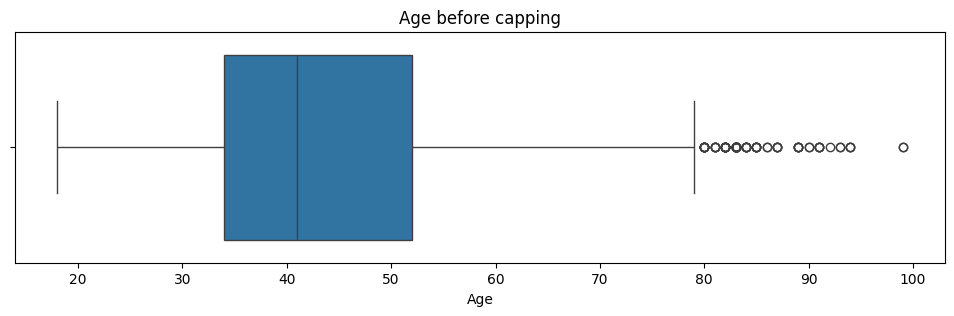

In [21]:
plt.figure(figsize=(12, 3))
sns.boxplot(x = df["Age"])
plt.title("Age before capping")
plt.show()

In [22]:
for i in ["Age", "Positive Feedback Count"]:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)
    print(i, "-> lower limit:", lower, " upper limit:", upper)
    df[i] = df[i].map(lambda x: lower if x < lower else upper if x > upper else x)

df["Age"] = df["Age"].astype(int)

Age -> lower limit: 7.0  upper limit: 79.0
Positive Feedback Count -> lower limit: -4.5  upper limit: 7.5


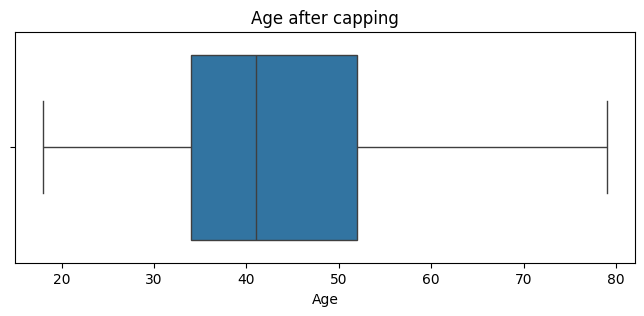

In [23]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["Age"])
plt.title("Age after capping")
plt.show()

### 5.5 Scaling (min-max)
Squeezes a column into 0 to 1 using: `(value - min) / (max - min)`

In [24]:
df["age_scaled"] = (df["Age"] - df["Age"].min()) / (df["Age"].max() - df["Age"].min())
df["word_count_scaled"] = (df["word_count"] - df["word_count"].min()) / (df["word_count"].max() - df["word_count"].min())

df[["Age", "age_scaled", "word_count", "word_count_scaled"]].head()

,Age,age_scaled,word_count,word_count_scaled
0,33,0.245902,7,0.043860
1,34,0.262295,64,0.543860
2,60,0.688525,97,0.833333
3,50,0.524590,23,0.184211
4,47,0.475410,36,0.298246


### 5.7 Encoding (text categories -> numbers, without sklearn)
- **Ordinal encoding** (order matters: Short < Medium < Long) -> `map` with a dictionary
- **Label encoding** (a number for each department) -> `.astype("category").cat.codes`
- **One-hot encoding** (a 0/1 column for each division) -> `pd.get_dummies`

In [25]:
# label encoding (a number for each department)
df["department_code"] = df["Department Name"].astype("category").cat.codes

# one-hot encoding (a 0/1 column for each division)
division_dummies = pd.get_dummies(df["Division Name"], prefix="division", dtype=int)
df = pd.concat([df, division_dummies], axis=1)

df[["Department Name", "department_code"]].head()

,Department Name,department_code
0,Intimate,2
1,Dresses,1
2,Dresses,1
3,Bottoms,0
4,Tops,4


### 5.8 Critical flag and Severity score
- `is_critical` = 1 if the rating is 1 or 2 stars
- `severity_score` = how bad the review is: **3 points for every missing star** + **1 point per negative word** + **2 points per complaint theme** + **2 points if the customer does not recommend the product**
- `priority_score` = scaled severity + scaled review length (so the worst **and** most detailed reviews come first)

In [26]:
df["is_critical"] = (df["Rating"] <= 2).astype(int)

df["severity_score"] = ((5 - df["Rating"]) * 3
                        + df["neg_word_count"]
                        + df["theme_count"] * 2
                        + (1 - df["Recommended IND"]) * 2)

df["severity_scaled"] = (df["severity_score"] - df["severity_score"].min()) / (df["severity_score"].max() - df["severity_score"].min())
df["priority_score"] = (df["severity_scaled"] + df["word_count_scaled"]).round(3)

df[["Rating", "is_critical", "severity_score", "priority_score"]].head()

,Rating,is_critical,severity_score,priority_score
0,4,0,3,0.164
1,5,0,1,0.584
2,3,0,14,1.393
3,5,0,0,0.184
4,5,0,0,0.298


### 5.9 Correlation heatmap of the new features

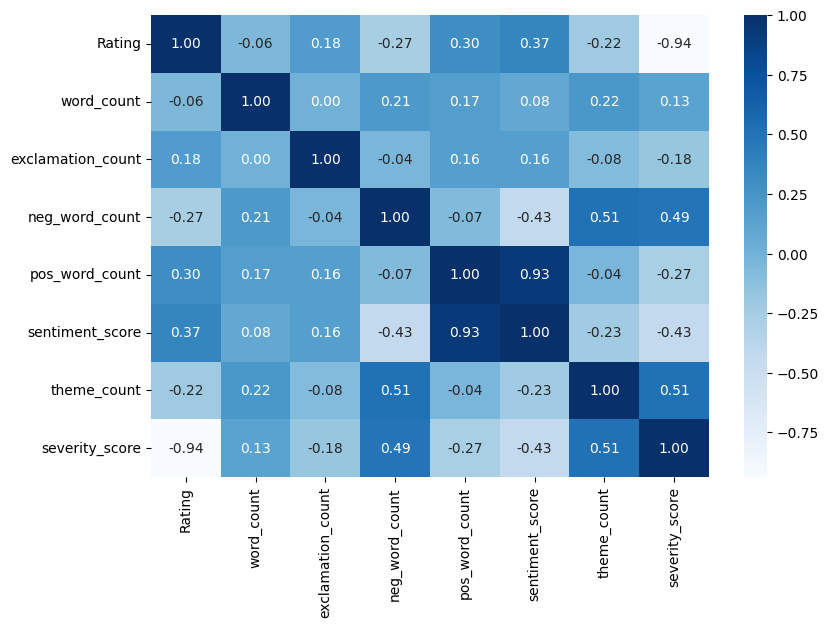

In [27]:
cols = ["Rating", "word_count", "exclamation_count", "neg_word_count", "pos_word_count",
        "sentiment_score", "theme_count", "severity_score"]

plt.figure(figsize=(9, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.show()

## 6. Rule-based filtering of Critical reviews (no ML)
**Critical review = 1 or 2 star rating.** Just a plain condition on the data.

Critical reviews: 2369 out of 22634
Percentage: 10.5 %


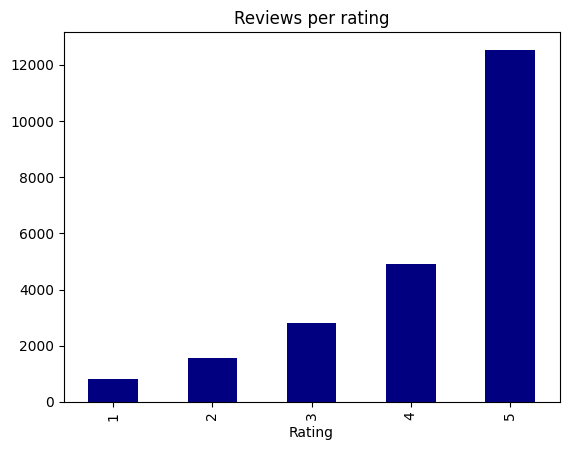

In [28]:
critical = df[df["Rating"] <= 2]

print("Critical reviews:", len(critical), "out of", len(df))
print("Percentage:", round(len(critical) / len(df) * 100, 1), "%")

df["Rating"].value_counts().sort_index().plot(kind="bar", color="navy")
plt.title("Reviews per rating")
plt.show()

## 7. Most common complaint keywords
We count every word of the critical reviews using a dictionary (like the `google.com` character-count example in class), ignoring common filler words.

In [29]:
stopwords = ["the", "and", "was", "for", "that", "this", "with", "have", "but", "not", "you", "are", "very", "they",
             "had", "its", "from", "would", "get", "just", "out", "she", "her", "all", "one", "too", "than", "when",
             "back", "after", "got", "did", "only", "will", "can", "were", "more", "like", "them", "what", "does",
             "has", "bought", "dress", "wear", "ordered", "order", "top", "shirt", "size", "didn", "don", "wasn", "doesn"]

word_count_dict = {}
for review in critical["clean_review"]:
    for word in review.split():
        if len(word) > 2 and word not in stopwords:
            if word in word_count_dict:
                word_count_dict[word] = word_count_dict[word] + 1
            else:
                word_count_dict[word] = 1

top_words = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)[:15]
top_words

[('fabric', 712),
 ('fit', 686),
 ('small', 517),
 ('look', 516),
 ('really', 474),
 ('love', 458),
 ('material', 428),
 ('looks', 400),
 ('much', 382),
 ('color', 380),
 ('looked', 376),
 ('even', 374),
 ('way', 367),
 ('also', 364),
 ('quality', 339)]

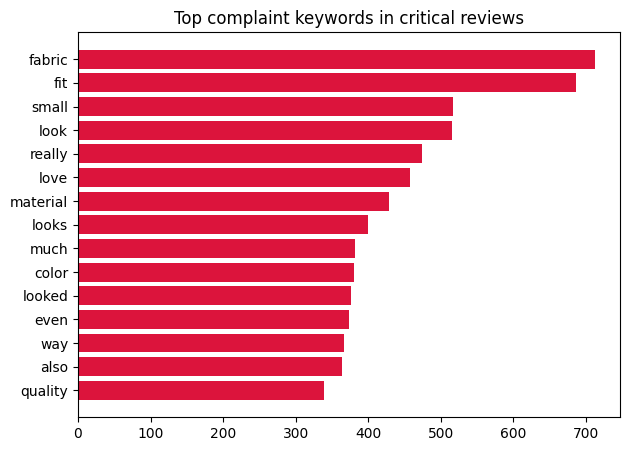

In [30]:
words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(7, 5))
plt.barh(words[::-1], counts[::-1], color="crimson")
plt.title("Top complaint keywords in critical reviews")
plt.show()

In [32]:
# which departments have the most critical reviews?
df.groupby("Department Name").agg(reviews=("Rating", "count"),
                                  critical=("is_critical", "sum"),
                                  avg_severity=("severity_score", "mean")).round(2)

,reviews,critical,avg_severity
Department Name,,,
Bottoms,3661,317,3.56
Dresses,6144,680,4.14
Intimate,1650,147,3.53
Jackets,1002,108,3.58
Tops,10059,1096,3.97
Trend,118,21,5.18


In [33]:
pd.crosstab(df["Department Name"], df["is_critical"])

is_critical,0,1
Department Name,,
Bottoms,3344,317
Dresses,5464,680
Intimate,1503,147
Jackets,894,108
Tops,8963,1096
Trend,97,21


## 8. Generative AI - apology emails
### Step A: pick the 3 reviews
The critical reviews with the highest `priority_score` (worst and most detailed).

In [34]:
top3 = critical.sort_values("priority_score", ascending=False).head(3).reset_index(drop=True)

top3[["Rating", "word_count", "priority_score", "Review Text"]]

,Rating,word_count,priority_score,Review Text
0,1,103,1.886,I was so excited to order this dress. i loved ...
1,1,94,1.767,"Generally, i find sizing at retailer to be ver..."
2,1,101,1.748,I had high hopes for this sweater and when i f...


### Step B: To send each review to Gemini


In [35]:
!pip install -q google-genai

In [38]:
from google import genai
from google.colab import userdata

client = genai.Client(api_key=userdata.get("Gemini_API_key"))
model_name = "gemini-3.8-flash"      # if you get a "model not found" error, change this to a current Gemini model

In [43]:
emails = []

for i, row in top3.iterrows():
    themes = [t.replace("theme_", "") for t in theme_cols if row[t] == 1]     # problems found by our rules

    prompt = f"""You are a friendly Customer Support Agent for an online clothing store.
A customer left this {row['Rating']}-star review:

"{row['Review Text']}"

Problems detected: {themes}

Write a short apology email (maximum 120 words) that:
- has a subject line and a greeting
- sincerely apologises and mentions the SPECIFIC problems the customer described
- offers a next step (refund, replacement or a call from our support team)
- sounds warm and human, and ends with "Customer Care Team"
Do not invent order numbers or facts that are not in the review."""

    response = client.models.generate_content(model=model_name, contents=prompt)
    emails.append(response.text)

print("Done -", len(emails), "emails generated")

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [44]:
output = "### AI-Generated Response Emails\n\n"
for i in range(len(emails)):
    output += f"#### Email {i + 1}\n**Original review:** *{top3.loc[i, 'Review Text']}*\n\n{emails[i]}\n\n---\n\n"

display(Markdown(output))

# save a copy of the emails
with open("generated_emails.md", "w") as f:
    f.write(output)

### AI-Generated Response Emails



## Summary
- Cleaned the data (missing values, duplicates, text cleaning).
- Built new features: text counts, positive/negative word counts, complaint themes, IQR outlier capping, binning, scaling, encoding, severity and priority scores.
- Critical reviews (1-2 stars) were found with a simple rule, and the top complaint keywords and themes were counted.
- Gemini wrote apology emails for the 3 most critical, detailed reviews.